# EPSP ratio comparison in low and high extracellular calcium

In [1]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import optimize, stats
from scipy.interpolate import griddata
from matplotlib import cm, colors
from itertools import product
from matplotlib.transforms import Affine2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from IPython.display import display
from epsp_ratio_summary_common import *

# Apply publication style
pubstyle = True

# Configure matplotlib
if pubstyle:
    plt.style.use('onerule.mplstyle')

In [2]:
# Load Markram 1997 data, including the low calcium simulations
highca_exp, highca_out, highca = load_insilico('data/insilico/markram_1997/L5TTPC_L5TTPC.csv')
lowca_exp, lowca_out, lowca = load_insilico('data/insilico/markram_1997/L5TTPC_L5TTPC_invivo.csv')

No outliers in data/insilico/markram_1997/L5TTPC_L5TTPC.csv
Data sample:


,pregid,postgid,frequency_train,dt_train,epsp_ratio,epsp_before
1431,160737,144433,30.0,50,0.881226,1.725978
445,145185,155180,50.0,-10,0.966552,2.653500
2817,152676,137887,10.0,50,0.629667,3.429046
4810,144144,142961,2.0,-50,1.004200,4.152858
2470,141511,137626,20.0,10,1.629596,0.911015


Aggregated data:


,frequency_train,dt_train,mean_epsp_ratio,std_epsp_ratio,sem_epsp_ratio,sample_size
0,2.0,-50,0.962318,0.116389,0.011639,100
1,2.0,-30,0.943111,0.133197,0.013320,100
2,2.0,-10,0.901727,0.156539,0.015654,100
3,2.0,5,0.987729,0.314079,0.031408,100
4,2.0,10,0.933250,0.312872,0.031287,100
5,2.0,30,0.915399,0.286644,0.028664,100
6,2.0,50,0.874544,0.246125,0.024612,100
7,5.0,-50,0.919176,0.169958,0.016996,100
8,5.0,-30,0.890221,0.188846,0.018885,100
9,5.0,-10,0.829130,0.214822,0.021482,100


No outliers in data/insilico/markram_1997/L5TTPC_L5TTPC_invivo.csv
Data sample:


,pregid,postgid,frequency_train,dt_train,epsp_ratio,epsp_before
1431,160737,144433,30.0,50,1.095678,0.286175
445,145185,155180,50.0,-10,0.589883,0.447733
2817,152676,137887,10.0,50,1.091492,0.571557
4810,144144,142961,2.0,-50,0.945648,0.682366
2470,141511,137626,20.0,10,1.067614,0.175068


Aggregated data:


,frequency_train,dt_train,mean_epsp_ratio,std_epsp_ratio,sem_epsp_ratio,sample_size
0,2.0,-50,1.008445,0.153120,0.015312,100
1,2.0,-30,1.017197,0.161259,0.016126,100
2,2.0,-10,1.021018,0.157176,0.015718,100
3,2.0,5,1.029648,0.196645,0.019664,100
4,2.0,10,1.042133,0.187116,0.018712,100
5,2.0,30,1.035941,0.175020,0.017502,100
6,2.0,50,0.983786,0.151771,0.015177,100
7,5.0,-50,0.996062,0.149213,0.014921,100
8,5.0,-30,1.001854,0.144309,0.014431,100
9,5.0,-10,1.015690,0.175825,0.017582,100


t-test results for frequency_train = 2.000000: s = 1.131, p = 0.260
t-test results for frequency_train = 5.000000: s = 2.022, p = 0.045
t-test results for frequency_train = 10.000000: s = -2.747, p = 0.007
t-test results for frequency_train = 20.000000: s = -6.631, p = 0.000
t-test results for frequency_train = 30.000000: s = -6.250, p = 0.000
t-test results for frequency_train = 40.000000: s = -5.246, p = 0.000
t-test results for frequency_train = 50.000000: s = -5.204, p = 0.000


Text(0.5, 1.0, '$\\Delta t$ = 5 ms')

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue


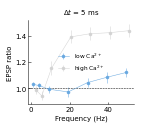

In [3]:
# Plot LTP freq
sel_lowca = lowca[lowca.dt_train==5]
sel_highca = highca[highca.dt_train==5]
fig, ax = plot_ratio(sel_lowca, r'low Ca$^{2+}$', sel_highca, r'high Ca$^{2+}$', style='diverge')
ax.set_title(r'$\Delta t$ = 5 ms')
#fig.savefig('l5_l5_ltp_lowca.svg')

t-test results for frequency_train = 2.000000: s = 5.378, p = 0.000
t-test results for frequency_train = 5.000000: s = 6.720, p = 0.000
t-test results for frequency_train = 10.000000: s = 2.948, p = 0.004
t-test results for frequency_train = 20.000000: s = -6.233, p = 0.000
t-test results for frequency_train = 30.000000: s = -6.339, p = 0.000
t-test results for frequency_train = 40.000000: s = -6.216, p = 0.000
t-test results for frequency_train = 50.000000: s = -6.145, p = 0.000


Text(0.5, 1.0, '$\\Delta t$ = -10 ms')

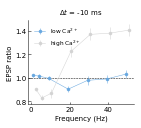

In [4]:
# Plot LTD freq
sel_lowca = lowca[lowca.dt_train==-10]
sel_highca = highca[highca.dt_train==-10]
fig, ax = plot_ratio(sel_lowca, r'low Ca$^{2+}$', sel_highca, r'high Ca$^{2+}$', style='diverge')
ax.set_title(r'$\Delta t$ = -10 ms')
#fig.savefig('l5_l5_ltd_lowca.svg')

t-test results for dt_train = -50.000000: s = -7.336, p = 0.000
t-test results for dt_train = -30.000000: s = -6.711, p = 0.000
t-test results for dt_train = -10.000000: s = -6.216, p = 0.000
t-test results for dt_train = 5.000000: s = -5.246, p = 0.000
t-test results for dt_train = 10.000000: s = -5.291, p = 0.000
t-test results for dt_train = 30.000000: s = -4.726, p = 0.000
t-test results for dt_train = 50.000000: s = -3.685, p = 0.000


Text(0.5, 1.0, 'Frequency = 40 Hz')

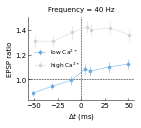

In [5]:
# Plot STDP
sel_lowca = lowca[lowca.frequency_train==40]
sel_highca = highca[highca.frequency_train==40]
fig, ax = plot_ratio(sel_lowca, r'low Ca$^{2+}$', sel_highca, r'high Ca$^{2+}$', xvar='dt_train', style='diverge')
ax.set_title('Frequency = 40 Hz')
#fig.savefig('l5_l5_stdp10_lowca.svg')

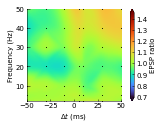

In [6]:
mapsize = np.array((6.2, 4.8))/3 if pubstyle else None
fig = plot_map(lowca, mapsize=mapsize)
#fig.savefig('l5_l5_map_lowca.svg')

/home/chindemi/OneRule/onerule/venv/lib/python3.8/site-packages/seaborn/axisgrid.py:88: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  self._figure.tight_layout(*args, **kwargs)


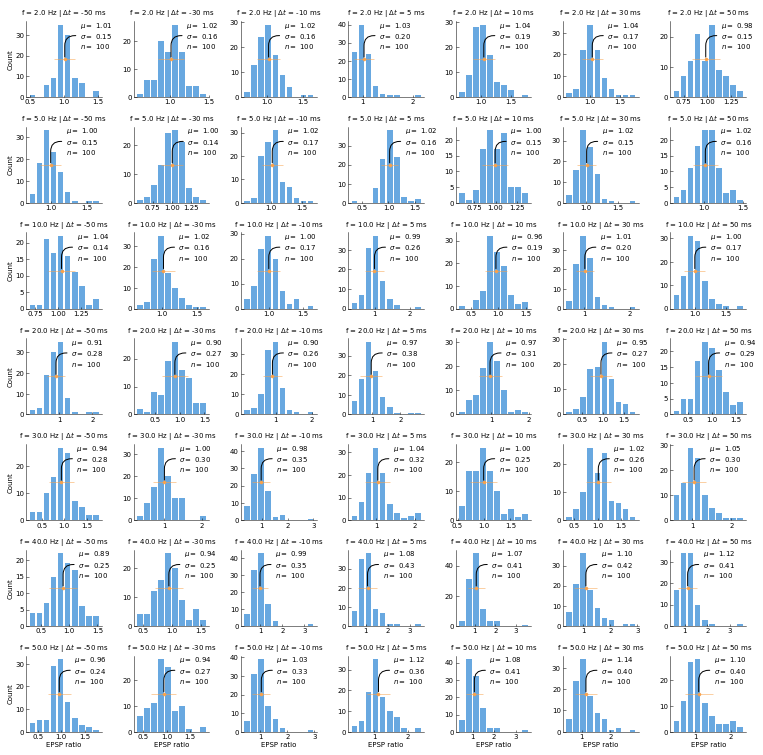

In [7]:
height = 1.5 if pubstyle else 3


def histerrplot(*args, **kwargs):
    data = kwargs.pop('data')
    xvar = kwargs.pop('x')
    values = data[xvar].values
    n = len(values)
    # Get axes
    ax = plt.gca()
    # Plot histograms
    ax.hist(values, rwidth=0.8)
    # Plot errorbar
    ymin, ymax = ax.get_ylim()
    y = (ymin + ymax)/2
    x = np.mean(values)
    xerr = np.std(values)
    ax.errorbar(x, y, xerr=xerr, fmt="-o")
    # Annotate mean and SEM
    arrowprops = dict(arrowstyle="-", connectionstyle="angle,angleA=0,angleB=90,rad=10")
    offset = 10
    ax.annotate("$\mu =$ %.2f\n$\sigma =$ %.2f\n$n =$ %d" % (x, xerr, n), (x, y),
                xytext=(1.5*offset, offset), textcoords='offset points',
                arrowprops=arrowprops)


# Rename columns for clarity
insilico_plot = lowca_exp.rename(columns={"frequency_train": "f",
                                          "dt_train": "$\Delta t$",
                                          "epsp_ratio": "EPSP ratio"})

# Plot grid
g = sns.FacetGrid(insilico_plot, sharex=False, sharey=False,
                  height=height, row="f", col="$\Delta t$")
g.map_dataframe(histerrplot, x="EPSP ratio")
g.set_titles('{row_var} = {row_name} Hz | {col_var} = {col_name} ms')
g.set_ylabels("Count")

g.savefig("l5_l5_lowca_hist.png", dpi=300)